<a href="https://colab.research.google.com/github/Sak-shi437/linear_regression/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df =pd.read_csv("/content/House Price Prediction Dataset.csv")

In [30]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [31]:
df["Location"].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [32]:
df.shape

(2000, 10)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [34]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [35]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [38]:
df.drop("Id",axis=1,inplace=True)

In [39]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [40]:
df["Garage"].unique()

array(['No', 'Yes'], dtype=object)

In [41]:
df["Garage"] = df["Garage"].map({
    "Yes":1,
    "No" : 0
})

In [42]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,0,149919
1,4272,5,4,3,1958,Downtown,Excellent,0,424998
2,3592,2,2,3,1938,Downtown,Good,0,266746
3,966,4,2,2,1902,Suburban,Fair,1,244020
4,4926,1,4,2,1975,Downtown,Fair,1,636056


In [43]:
# One-Hot Encode Location and Condition
df = pd.get_dummies(
    df,
    columns=["Location", "Condition"],
    drop_first=True
)

In [44]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,0,149919,False,False,False,False,False,False
1,4272,5,4,3,1958,0,424998,False,False,False,False,False,False
2,3592,2,2,3,1938,0,266746,False,False,False,False,True,False
3,966,4,2,2,1902,1,244020,False,True,False,True,False,False
4,4926,1,4,2,1975,1,636056,False,False,False,True,False,False


In [45]:
df["Location_Rural"] = df["Location_Rural"].astype(int)

In [46]:
df["Location_Suburban"] = df["Location_Suburban"].astype(int)

In [47]:
df["Location_Urban"] = df["Location_Urban"].astype(int)

In [48]:
df["Condition_Fair"] = df["Condition_Fair"].astype(int)

In [49]:
df["Condition_Good"] = df["Condition_Good"].astype(int)

In [50]:
df["Condition_Poor"] = df["Condition_Poor"].astype(int)

In [51]:
df.head()


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,0,149919,0,0,0,0,0,0
1,4272,5,4,3,1958,0,424998,0,0,0,0,0,0
2,3592,2,2,3,1938,0,266746,0,0,0,0,1,0
3,966,4,2,2,1902,1,244020,0,1,0,1,0,0
4,4926,1,4,2,1975,1,636056,0,0,0,1,0,0


In [52]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
lr = LinearRegression()

In [57]:
lr.fit(X_train,y_train)

LinearRegression()

In [58]:
X_test

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
1860,633,1,4,2,1901,0,0,0,1,1,0,0
353,3856,1,1,2,1901,0,0,0,1,1,0,0
1333,1598,5,4,1,2013,0,0,0,1,0,0,0
905,1705,3,1,2,1996,1,0,0,0,0,1,0
1289,2564,5,2,3,1994,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
965,1811,1,3,3,1970,0,1,0,0,0,0,1
1284,794,3,2,2,2013,1,0,0,0,0,0,1
1739,3540,4,4,2,1939,1,0,0,0,0,0,1
261,3670,5,2,2,1910,1,0,0,0,0,1,0


In [59]:
y_test

,Price
1860,514764
353,694256
1333,66375
905,650243
1289,223285
...,...
965,386940
1284,632570
1739,494049
261,562193


In [61]:
lr.predict(X_test.iloc[[0]])

array([521988.22189839])

In [62]:
y_pred = lr.predict(X_test)

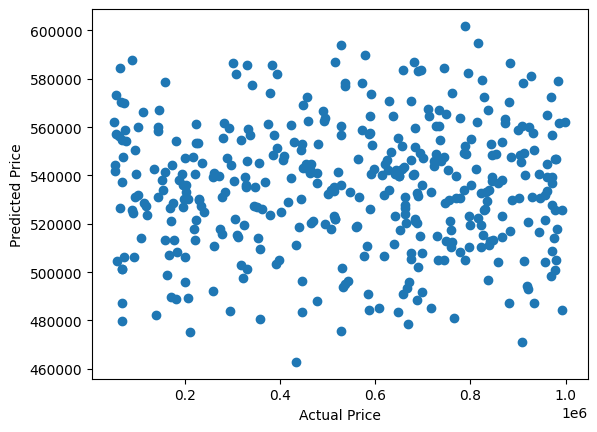

In [70]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [65]:
X = df[['Area']]
y = df['Price']

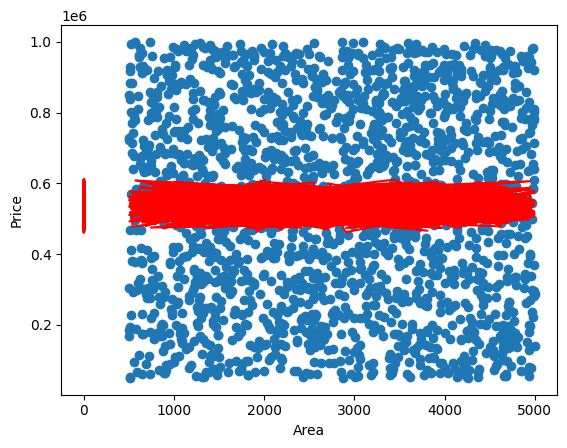

In [71]:
plt.scatter(df['Area'], df['Price'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [72]:
m = lr.coef_

In [73]:
b = lr.intercept_

In [69]:
m * 8.58 + b

array([278515.59115426, 279179.34493385, 195618.44127149, 482106.63069704,
       279529.65825319, 298885.42348997, 289825.04165203, 377293.40373392,
       169392.20685969, 485155.31244512, 167486.3664359 , 313469.17854483])

In [74]:
print("Train Score:", lr.score(X_train, y_train))
print("Test Score:", lr.score(X_test, y_test))

Train Score: 0.009856184863687778
Test Score: -0.006717808430749761


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 243241.97758826384
RMSE: 279859.72583784326
R2: -0.006717808430749761
